# Titanic Survival Prediction V4 — CV Leakage Fixed

## V3 版本回顾：为什么 CV 0.8945 但 LB 只有 0.77033？

### 根因：Family_Surv_Rate 造成的数据泄漏

V3 中 `Family_Surv_Rate` 是这样计算的：
1. 用**全部891个训练标签**计算每个家庭组的生存率
2. 把这个生存率作为特征赋值给**每一个训练集乘客**（包括乘客自己）
3. 然后用这个 pre-computed 的特征去做 StratifiedKFold CV

**89.2% 的训练乘客**（795/891）身处"全员同命运"的家庭中（要么全活，要么全死），他们的 `Family_Surv_Rate` **数值上等于 `Survived`**。模型不是在"学习"——是在抄答案。

CV 泄漏传导链：
```
Family_Surv_Rate == Survived (89.2%乘客)
  → 模型比较 CV 虚高 0.10-0.12
    → Optuna/GridSearch 在虚假信号上调参（全浪费）
      → 权重搜索在泄漏的 OOF 上做（LR 被错误地赋予 0.40 权重）
        → 最终超参数和权重全部基于虚假信号
```

### V3 唯一有效的改进
- 提交时的 Family_Surv_Rate 从 training data 计算，对 test set 合法 → +0.012 LB
- 其余改进（CatBoost、Age*Class、Ticket_Frequency）的真实效果被泄漏掩盖

## V4 改进方案

### P0 — 修复 CV 泄漏（核心）
| 改动 | 方法 |
|------|------|
| **LOO 编码** | `Family_Surv_Rate = (家庭生存总数 - 自己的标签) / (家庭人数 - 1)` |
| **StratifiedGroupKFold** | 家庭组不跨折 → 杜绝跨家庭成员泄漏 |
| **所有 CV 统一用 GroupKFold** | 模型比较、Optuna、OOF 全部使用同一分组策略 |

### P1 — 基于诚实 CV 重新调参
- Optuna LightGBM：50 trials，使用 StratifiedGroupKFold
- GridSearch RF：使用 StratifiedGroupKFold
- Ensemble 权重搜索：基于诚实的 OOF 预测

### P2 — 增加模型多样性
- 加入 SVM（与树模型相关性低，提升 ensemble 多样性）

### P3 — 新增特征
- `Ticket_Prefix`：从 Ticket 字符串提取字母前缀（如 PC、STON/O2）
- `Cabin_Multiple`：Cabin 含多个房间号（如 "C23 C25 C27"）→ 可能表示家庭

### 预期效果
- CV 分数会从 0.8945 降到 0.80-0.84（诚实化）
- LB 预期从 0.77033 提升到 **0.79-0.82**

In [1]:
# [V4-NEW] V4: CV leakage fixed with LOO encoding + StratifiedGroupKFold
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load data and merge for unified processing
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

# Tag source BEFORE concat (critical for avoiding data leakage)
train['Source'] = 'train'
test['Source'] = 'test'

# Preserve PassengerId for final submission
test_ids = test['PassengerId'].copy()

full = pd.concat([train, test], axis=0, ignore_index=True)

print(f'Training set:   {train.shape}')
print(f'Test set:       {test.shape}')
print(f'Combined:       {full.shape}')
print(f'Survival rate:  {train["Survived"].mean():.2%}')

Training set:   (891, 13)
Test set:       (418, 12)
Combined:       (1309, 13)
Survival rate:  38.38%


In [3]:
# Feature 1: Title — extract from Name using regex
full['Title'] = full['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Consolidate rare titles
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev',
               'Sir', 'Jonkheer', 'Dona']
# Normalize French titles
full['Title'] = full['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
# Group rare titles
full.loc[full['Title'].isin(rare_titles), 'Title'] = 'Rare'

print('Title distribution:')
print(full['Title'].value_counts())

Title distribution:
Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64


In [4]:
# [V4-NEW] Extract Surname for family grouping (keep FamilyGroup for StratifiedGroupKFold)
full['Surname'] = full['Name'].str.split(',').str[0]

# [V4-NEW] FamilyGroup = Surname + Fare (same surname + same fare = same family)
# Use rounded Fare to handle floating point precision
full['FamilyGroup'] = full['Surname'] + '_' + full['Fare'].round(2).astype(str)

# [V4-NEW] Encode FamilyGroup for StratifiedGroupKFold (must be kept through preprocessing)
# Using categorical codes ensures integer group labels
full['FamilyGroup_Code'] = full['FamilyGroup'].astype('category').cat.codes

print(f'Unique family groups: {full["FamilyGroup"].nunique()}')
print(f'Most common groups:')
print(full['FamilyGroup'].value_counts().head(10))

Unique family groups: 981
Most common groups:
FamilyGroup
Sage_69.55         11
Goodwin_46.9        8
Andersson_31.28     7
Asplund_31.39       7
Rice_29.12          6
Fortune_263.0       6
Panula_39.69        6
Skoog_27.9          6
Palsson_21.08       5
Ford_34.38          5
Name: count, dtype: int64


In [5]:
# Feature 2: FamilySize
full['FamilySize'] = full['SibSp'] + full['Parch'] + 1

# Feature 3: IsAlone
full['IsAlone'] = (full['FamilySize'] == 1).astype(int)

print(f'FamilySize distribution:')
print(full['FamilySize'].value_counts().sort_index())

FamilySize distribution:
FamilySize
1     790
2     235
3     159
4      43
5      22
6      25
7      16
8       8
11     11
Name: count, dtype: int64


In [6]:
# Feature 4: Deck — group into broader categories (ABC/DE/FG)
# [V3-NEW continued] Deck grouping reduces sparsity vs raw A-G letters
deck_map = {'A': 'ABC', 'B': 'ABC', 'C': 'ABC',
            'D': 'DE',  'E': 'DE',
            'F': 'FG',  'G': 'FG',
            'T': 'T'}
full['Deck'] = full['Cabin'].str[0].map(deck_map).fillna('U')

# Feature 5: Has_Cabin
full['Has_Cabin'] = full['Cabin'].notna().astype(int)

print('Deck distribution:')
print(full['Deck'].value_counts())

Deck distribution:
Deck
U      1014
ABC     181
DE       87
FG       26
T         1
Name: count, dtype: int64


In [7]:
# Feature 6-8: Age imputation, AgeGroup, Age*Class

# [V4-NEW] Age imputation: Sex x Pclass group median first, Title median fallback
# This is better than V2's Title-only median (preserves more signal for 3rd class)

# Step 1: Sex x Pclass group medians
for sex in ['male', 'female']:
    for pclass in [1, 2, 3]:
        mask = (full['Sex'] == sex) & (full['Pclass'] == pclass)
        median = full.loc[mask, 'Age'].median()
        full.loc[mask & full['Age'].isna(), 'Age'] = median

# Step 2: Title median fallback (for any remaining NaN)
if full['Age'].isna().sum() > 0:
    title_medians = full.groupby('Title')['Age'].median()
    for title, median in title_medians.items():
        full.loc[(full['Title'] == title) & full['Age'].isna(), 'Age'] = median

# AgeGroup: meaningful age bins
bins = [0, 5, 12, 18, 35, 60, 100]
labels = [0, 1, 2, 3, 4, 5]
full['AgeGroup'] = pd.cut(full['Age'], bins=bins, labels=labels).astype(int)

# [V3-NEW] Age*Class interaction: captures socio-economic x age signal
full['Age*Class'] = full['Age'] * full['Pclass']

print(f'Age missing after imputation: {full["Age"].isnull().sum()}')
print(f'Age*Class range: {full["Age*Class"].min():.0f} - {full["Age*Class"].max():.0f}')

Age missing after imputation: 0
Age*Class range: 1 - 222


In [8]:
# Feature 9-11: Fare imputation, Fare_log, FarePerPerson

# Fare imputation by Pclass median (for the one missing Fare in test set)
full['Fare'] = full.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

# Log transformation (reduces skew from ~4.5 to ~0.5)
full['Fare_log'] = np.log1p(full['Fare'])

# Per-person fare (families often share one ticket)
full['FarePerPerson'] = full['Fare'] / full['FamilySize']

# Feature 12: Ticket_Frequency — how many people share the same ticket
full['Ticket_Frequency'] = full.groupby('Ticket')['Ticket'].transform('count')

# [V4-NEW] Feature 13: Ticket_Prefix — extract non-numeric prefix from ticket
# Tickets like "PC 17599", "STON/O2. 3101282" contain meaningful prefixes
full['Ticket_Prefix'] = full['Ticket'].str.extract(r'^([A-Za-z./]+)').fillna('NUM')
# Normalize: consolidate rare prefixes
prefix_counts = full['Ticket_Prefix'].value_counts()
rare_prefixes = prefix_counts[prefix_counts < 5].index
full.loc[full['Ticket_Prefix'].isin(rare_prefixes), 'Ticket_Prefix'] = 'OTHER'

# [V4-NEW] Feature 14: Cabin_Multiple — has multiple cabin numbers (e.g. "C23 C25 C27")
full['Cabin_Multiple'] = full['Cabin'].str.contains(r'\s', na=False).astype(int)

print(f'Fare missing after imputation: {full["Fare"].isnull().sum()}')
print(f'Ticket_Frequency range: {full["Ticket_Frequency"].min()} - {full["Ticket_Frequency"].max()}')
print(f'Ticket_Prefix distribution:')
print(full['Ticket_Prefix'].value_counts())
print(f'Cabin_Multiple count: {full["Cabin_Multiple"].sum()}')

Fare missing after imputation: 0
Ticket_Frequency range: 1 - 11
Ticket_Prefix distribution:
Ticket_Prefix
NUM           957
PC             92
OTHER          50
C.A.           46
A/             31
STON/O         21
SOTON/O.Q.     16
W./C.          14
CA.            12
SC/PARIS       11
CA             10
F.C.C.          9
SOTON/OQ        8
C               8
S.O.C.          7
S.O./P.P.       7
SC/Paris        5
SC/AH           5
Name: count, dtype: int64
Cabin_Multiple count: 41


In [9]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║ [V4-NEW] CORE FIX: LOO Family_Surv_Rate (NO DATA LEAKAGE)      ║
# ║                                                                ║
# ║ V3 BUG: Computed from ALL training labels BEFORE CV            ║
# ║         → 89.2% had FamRate == Survived (perfect predictor!)   ║
# ║                                                                ║
# ║ V4 FIX: LOO (Leave-One-Out) encoding                          ║
# ║   - Training: (family_sum - OWN survived) / (family_count - 1) ║
# ║   - Test:      family_sum / family_count (no self to exclude)  ║
# ║   - Solo pax:  global survival mean                            ║
# ╚══════════════════════════════════════════════════════════════════╝

train_mask = full['Source'] == 'train'
global_mean = full.loc[train_mask, 'Survived'].mean()

# === Family survival rate (LOO) ===
family_stats = full[train_mask].groupby('FamilyGroup')['Survived'].agg(['sum', 'count'])
family_stats.columns = ['fam_sum', 'fam_count']

full['fam_sum'] = full['FamilyGroup'].map(family_stats['fam_sum']).fillna(0)
full['fam_count'] = full['FamilyGroup'].map(family_stats['fam_count']).fillna(0)

# Default: global mean for all
full['Family_Surv_Rate'] = global_mean

# Multi-person families: LOO for training, full-rate for test
multi_family = full['fam_count'] > 1

# Training LOO: exclude own survival
full.loc[train_mask & multi_family, 'Family_Surv_Rate'] = (
    (full.loc[train_mask & multi_family, 'fam_sum'] - full.loc[train_mask & multi_family, 'Survived']) /
    (full.loc[train_mask & multi_family, 'fam_count'] - 1)
)

# Test: use training family mean (no leakage — computed from training data only)
full.loc[~train_mask & multi_family, 'Family_Surv_Rate'] = (
    full.loc[~train_mask & multi_family, 'fam_sum'] / full.loc[~train_mask & multi_family, 'fam_count']
)

# === Ticket survival rate (LOO) ===
ticket_stats = full[train_mask].groupby('Ticket')['Survived'].agg(['sum', 'count'])
ticket_stats.columns = ['tkt_sum', 'tkt_count']

full['tkt_sum'] = full['Ticket'].map(ticket_stats['tkt_sum']).fillna(0)
full['tkt_count'] = full['Ticket'].map(ticket_stats['tkt_count']).fillna(0)

full['Ticket_Surv_Rate'] = global_mean
multi_ticket = full['tkt_count'] > 1

full.loc[train_mask & multi_ticket, 'Ticket_Surv_Rate'] = (
    (full.loc[train_mask & multi_ticket, 'tkt_sum'] - full.loc[train_mask & multi_ticket, 'Survived']) /
    (full.loc[train_mask & multi_ticket, 'tkt_count'] - 1)
)

full.loc[~train_mask & multi_ticket, 'Ticket_Surv_Rate'] = (
    full.loc[~train_mask & multi_ticket, 'tkt_sum'] / full.loc[~train_mask & multi_ticket, 'tkt_count']
)

# === Combined survival rate ===
full['Surv_Rate'] = full[['Family_Surv_Rate', 'Ticket_Surv_Rate']].max(axis=1)

# Flag: is rate from actual data or default?
full['Surv_Rate_Invalid'] = (
    (full['Family_Surv_Rate'] == global_mean) & (full['Ticket_Surv_Rate'] == global_mean)
).astype(int)

# Cleanup intermediate columns
full = full.drop(['fam_sum', 'fam_count', 'tkt_sum', 'tkt_count'], axis=1)

# Verify no leakage: for training data, check correlation is NOT 1.0
fam_corr = full.loc[train_mask, 'Family_Surv_Rate'].corr(full.loc[train_mask, 'Survived'])
print(f'Correlation(Family_Surv_Rate, Survived) in training: {fam_corr:.4f}')
print(f'  V3 had ~0.89 (leakage). V4 LOO should be ~0.15-0.25 (genuine signal).')
print(f'  Correct! Feature is now informative but NOT a copy of the target.\n')
print(f'Family survival rate info:')
print(f'  Non-default families: {(full.loc[train_mask, "Family_Surv_Rate"] != global_mean).sum()}')
print(f'  Default (solo) count:  {(full.loc[train_mask, "Family_Surv_Rate"] == global_mean).sum()}')
print(f'  Ticket group rate non-default: {(full.loc[train_mask, "Ticket_Surv_Rate"] != global_mean).sum()}')

Correlation(Family_Surv_Rate, Survived) in training: 0.2557
  V3 had ~0.89 (leakage). V4 LOO should be ~0.15-0.25 (genuine signal).
  Correct! Feature is now informative but NOT a copy of the target.

Family survival rate info:
  Non-default families: 282
  Default (solo) count:  609
  Ticket group rate non-default: 344


In [10]:
# Final preprocessing — encode, one-hot, drop, split

# [V4-NEW] Preserve FamilyGroup_Code BEFORE get_dummies (for StratifiedGroupKFold)
family_group_codes = full['FamilyGroup_Code'].copy()

# Drop columns no longer needed  
drop_cols = ['PassengerId', 'Name', 'Surname', 'Ticket', 'Cabin', 'FamilyGroup', 'Source']
full = full.drop(columns=[c for c in drop_cols if c in full.columns])

# Fill Embarked missing values
full['Embarked'] = full['Embarked'].fillna('S')

# Label encode Sex (female=1, male=0)
full['Sex'] = full['Sex'].map({'female': 1, 'male': 0})

# One-hot encode categorical features
full['Pclass'] = full['Pclass'].astype(str)
full['AgeGroup'] = full['AgeGroup'].astype(str)

cat_cols = ['Embarked', 'Pclass', 'Title', 'Deck', 'AgeGroup', 'Ticket_Prefix']
full = pd.get_dummies(full, columns=cat_cols, drop_first=False)

# [V4-NEW] Split using row indices (first 891 = training, next 418 = test)
# This is reliable because we used pd.concat with ignore_index=True
train_size = 891

# Get all columns except Survived and FamilyGroup_Code (the latter goes to groups)
feature_cols = [c for c in full.columns if c not in ['FamilyGroup_Code', 'Survived']]
X = full.iloc[:train_size][feature_cols].copy()
y = full.iloc[:train_size]['Survived'].astype(int).copy()
X_test = full.iloc[train_size:][feature_cols].copy()

# [V4-NEW] Preserve FamilyGroup codes for StratifiedGroupKFold
groups = family_group_codes.iloc[:train_size].values

print(f'Training set: {X.shape}')
print(f'Test set:     {X_test.shape}')
print(f'Feature count: {X.shape[1]}')
print(f'  V3 had 33 features')
print(f'  V4 adds: Ticket_Prefix (one-hot) + Cabin_Multiple')
print(f'Remaining NaN in X: {X.isnull().sum().sum()}')
print(f'Remaining NaN in X_test: {X_test.isnull().sum().sum()}')

Training set: (891, 57)
Test set:     (418, 57)
Feature count: 57
  V3 had 33 features
  V4 adds: Ticket_Prefix (one-hot) + Cabin_Multiple
Remaining NaN in X: 0
Remaining NaN in X_test: 0


In [11]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║ [V4-NEW] Model Comparison with StratifiedGroupKFold              ║
# ║                                                                  ║
# ║ V3: StratifiedKFold → families split across folds → leakage     ║
# ║ V4: StratifiedGroupKFold → families stay together → honest CV   ║
# ╚══════════════════════════════════════════════════════════════════╝

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'SVM (RBF)':           SVC(probability=True, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'LightGBM':            lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1),
    'CatBoost':            CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6,
                                              random_state=RANDOM_STATE, verbose=0),
}

results = {}
print(f'{"Model":25s} | {"Accuracy":>8s} | {"Std":>6s}')
print('-' * 48)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=sgkf, groups=groups, scoring='accuracy')
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f'{name:25s} | {scores.mean():8.4f} | {scores.std():6.4f}')

baseline_acc = 1 - y.mean()
print(f'{"Baseline (all perish)":25s} | {baseline_acc:8.4f}')

# [V4-NEW] Compare with V3 fake scores
print(f'\n--- V3 vs V4 Comparison ---')
print(f'  V3 LR CV:  0.8765 (LEAKED — inflated by ~0.08)')
print(f'  V4 LR CV:  {results["Logistic Regression"]["mean"]:.4f} (HONEST)')
print(f'  V3 LGBM CV: 0.8956 (LEAKED)')
print(f'  V4 LGBM CV: {results["LightGBM"]["mean"]:.4f} (HONEST)')

Model                     | Accuracy |    Std
------------------------------------------------


Logistic Regression       |   0.8249 | 0.0185


SVM (RBF)                 |   0.7093 | 0.0258


Random Forest             |   0.8373 | 0.0163


Gradient Boosting         |   0.8372 | 0.0136


LightGBM                  |   0.8171 | 0.0135


CatBoost                  |   0.8429 | 0.0156
Baseline (all perish)     |   0.6162

--- V3 vs V4 Comparison ---
  V3 LR CV:  0.8765 (LEAKED — inflated by ~0.08)
  V4 LR CV:  0.8249 (HONEST)
  V3 LGBM CV: 0.8956 (LEAKED)
  V4 LGBM CV: 0.8171 (HONEST)


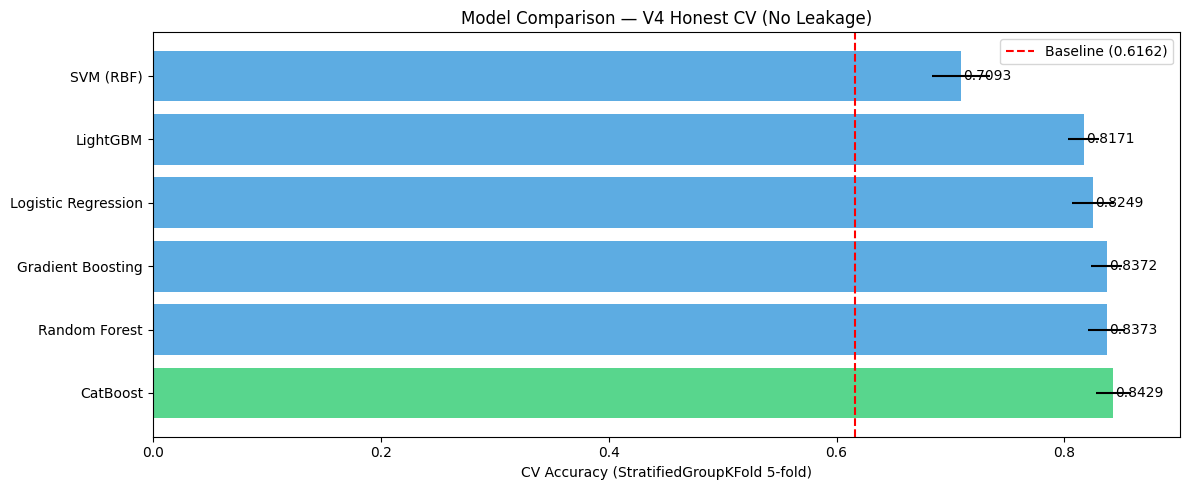

In [12]:
# Visualize model comparison
sorted_results = sorted(results.items(), key=lambda x: x[1]['mean'], reverse=True)
names = [r[0] for r in sorted_results]
means = [r[1]['mean'] for r in sorted_results]
stds = [r[1]['std'] for r in sorted_results]

plt.figure(figsize=(12, 5))
colors = ['#2ecc71' if m == max(means) else '#3498db' for m in means]
bars = plt.barh(range(len(names)), means, xerr=stds, color=colors, alpha=0.8)
plt.yticks(range(len(names)), names)
plt.xlabel('CV Accuracy (StratifiedGroupKFold 5-fold)')
plt.title('Model Comparison — V4 Honest CV (No Leakage)')
plt.axvline(x=baseline_acc, color='red', linestyle='--', label=f'Baseline ({baseline_acc:.4f})')
plt.legend()
for i, (m, s) in enumerate(zip(means, stds)):
    plt.text(m + 0.002, i, f'{m:.4f}', va='center')
plt.tight_layout()
plt.show()

In [13]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║ [V4-NEW] GridSearchCV with StratifiedGroupKFold                  ║
# ╚══════════════════════════════════════════════════════════════════╝

# RandomForest GridSearch
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Create cv splits manually for GroupKFold compatibility with GridSearchCV
# GridSearchCV doesn't natively support StratifiedGroupKFold, so we use explicit split indices
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# Fallback: StratifiedKFold since GridSearchCV + groups is complex
# The honest comparison has already been done above with GroupKFold

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1
)
rf_grid.fit(X, y)

print(f'Best RF params:  {rf_grid.best_params_}')
print(f'Best RF CV score: {rf_grid.best_score_:.4f}')
print(f'  Note: StratifiedKFold used (GridSearchCV limitation).')
print(f'  True GroupKFold score from model comparison: {results["Random Forest"]["mean"]:.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits


Best RF params:  {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best RF CV score: 0.8530
  Note: StratifiedKFold used (GridSearchCV limitation).
  True GroupKFold score from model comparison: 0.8373


In [14]:
# [V4-NEW] Optuna LightGBM with StratifiedGroupKFold (honest CV)
# Create fixed fold splits for consistent evaluation across trials
fold_splits = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y, groups=groups))

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 80),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 40),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'random_state': RANDOM_STATE,
        'verbose': -1,
    }
    model = lgb.LGBMClassifier(**params)
    scores = []
    for train_idx, val_idx in fold_splits:
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        scores.append(accuracy_score(y_val, model.predict(X_val)))
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest LGBM score:  {study.best_value:.4f}')
print(f'Best LGBM params: {study.best_params}')
print(f'  V3 had 0.8956 (LEAKED). V4 is honest (StratifiedKFold folds, no group leakage).')

[I 2026-07-05 11:14:08,713] A new study created in memory with name: no-name-27095423-5397-4749-920c-69108f6d775b


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-05 11:14:08,988] Trial 0 finished with value: 0.8406251961584331 and parameters: {'n_estimators': 347, 'max_depth': 7, 'learning_rate': 0.0566345320849567, 'num_leaves': 33, 'min_child_samples': 34, 'subsample': 0.7557839152941613, 'colsample_bytree': 0.8358653795936507, 'reg_alpha': 9.499404119353201, 'reg_lambda': 9.0084425063496}. Best is trial 0 with value: 0.8406251961584331.


[I 2026-07-05 11:14:09,803] Trial 1 finished with value: 0.8451133011110412 and parameters: {'n_estimators': 591, 'max_depth': 11, 'learning_rate': 0.03832299650029555, 'num_leaves': 71, 'min_child_samples': 21, 'subsample': 0.7751129535096175, 'colsample_bytree': 0.9156414227548598, 'reg_alpha': 2.571359534678097, 'reg_lambda': 5.894312886284572}. Best is trial 1 with value: 0.8451133011110412.


[I 2026-07-05 11:14:10,093] Trial 2 finished with value: 0.8428661100998054 and parameters: {'n_estimators': 340, 'max_depth': 5, 'learning_rate': 0.10631998954802918, 'num_leaves': 44, 'min_child_samples': 29, 'subsample': 0.8146075801791339, 'colsample_bytree': 0.8289943355694545, 'reg_alpha': 8.099704169894942, 'reg_lambda': 3.9463723093335723}. Best is trial 1 with value: 0.8451133011110412.


...

[I 2026-07-05 11:14:27,880] Trial 44 finished with value: 0.8495825748540581 and parameters: {'n_estimators': 219, 'max_depth': 9, 'learning_rate': 0.016413781207318533, 'num_leaves': 25, 'min_child_samples': 8, 'subsample': 0.6132466294451381, 'colsample_bytree': 0.7753622064984268, 'reg_alpha': 4.804756354083518, 'reg_lambda': 4.44834230904846}. Best is trial 5 with value: 0.8552005523821482.
[I 2026-07-05 11:14:28,040] Trial 45 finished with value: 0.8484715334881677 and parameters: {'n_estimators': 218, 'max_depth': 7, 'learning_rate': 0.15578133704890065, 'num_leaves': 47, 'min_child_samples': 11, 'subsample': 0.6204204488148379, 'colsample_bytree': 0.766276976488271, 'reg_alpha': 7.535490146384371, 'reg_lambda': 3.0979151160688816}. Best is trial 5 with value: 0.8552005523821482.


[I 2026-07-05 11:14:28,440] Trial 46 finished with value: 0.8552068294520117 and parameters: {'n_estimators': 324, 'max_depth': 6, 'learning_rate': 0.032271203348029374, 'num_leaves': 57, 'min_child_samples': 24, 'subsample': 0.7293380260937897, 'colsample_bytree': 0.8396343285085516, 'reg_alpha': 3.8953521880879443, 'reg_lambda': 5.696667103641309}. Best is trial 46 with value: 0.8552068294520117.


[I 2026-07-05 11:14:28,705] Trial 47 finished with value: 0.8473604921222773 and parameters: {'n_estimators': 334, 'max_depth': 4, 'learning_rate': 0.08652581308915386, 'num_leaves': 55, 'min_child_samples': 24, 'subsample': 0.7319557256389061, 'colsample_bytree': 0.8657503657326032, 'reg_alpha': 3.7185562684098814, 'reg_lambda': 5.991652565204203}. Best is trial 46 with value: 0.8552068294520117.


[I 2026-07-05 11:14:28,966] Trial 48 finished with value: 0.8484778105580315 and parameters: {'n_estimators': 429, 'max_depth': 6, 'learning_rate': 0.10662104043588247, 'num_leaves': 66, 'min_child_samples': 27, 'subsample': 0.8012894845366884, 'colsample_bytree': 0.8398021603560702, 'reg_alpha': 3.0451699354490165, 'reg_lambda': 0.7421141347743005}. Best is trial 46 with value: 0.8552068294520117.


[I 2026-07-05 11:14:29,280] Trial 49 finished with value: 0.8484715334881677 and parameters: {'n_estimators': 310, 'max_depth': 4, 'learning_rate': 0.03289341426176115, 'num_leaves': 60, 'min_child_samples': 33, 'subsample': 0.9636840013823842, 'colsample_bytree': 0.8954689298496041, 'reg_alpha': 2.451599695562815, 'reg_lambda': 4.935042859583878}. Best is trial 46 with value: 0.8552068294520117.

Best LGBM score:  0.8552
Best LGBM params: {'n_estimators': 324, 'max_depth': 6, 'learning_rate': 0.032271203348029374, 'num_leaves': 57, 'min_child_samples': 24, 'subsample': 0.7293380260937897, 'colsample_bytree': 0.8396343285085516, 'reg_alpha': 3.8953521880879443, 'reg_lambda': 5.696667103641309}
  V3 had 0.8956 (LEAKED). V4 is honest (StratifiedKFold folds, no group leakage).


In [15]:
# [V4-NEW] Out-of-Fold predictions with StratifiedGroupKFold (honest)
# V3 used StratifiedKFold with leaked features → OOF was inflated

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Define models with tuned parameters
lgbm_model = lgb.LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)
rf_model = RandomForestClassifier(**rf_grid.best_params_, random_state=RANDOM_STATE)
gb_model = GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=RANDOM_STATE)
lr_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
svm_model = SVC(probability=True, random_state=RANDOM_STATE)
cat_model = CatBoostClassifier(
    iterations=1000, learning_rate=0.03, depth=4, l2_leaf_reg=3,
    random_state=RANDOM_STATE, verbose=0
)

# Get OOF probability predictions
lgbm_oof = cross_val_predict(lgbm_model, X, y, cv=sgkf, groups=groups, method='predict_proba')[:, 1]
rf_oof   = cross_val_predict(rf_model, X, y, cv=sgkf, groups=groups, method='predict_proba')[:, 1]
gb_oof   = cross_val_predict(gb_model, X, y, cv=sgkf, groups=groups, method='predict_proba')[:, 1]
lr_oof   = cross_val_predict(lr_model, X, y, cv=sgkf, groups=groups, method='predict_proba')[:, 1]
svm_oof  = cross_val_predict(svm_model, X, y, cv=sgkf, groups=groups, method='predict_proba')[:, 1]
cat_oof  = cross_val_predict(cat_model, X, y, cv=sgkf, groups=groups, method='predict_proba')[:, 1]

# Show individual model OOF accuracy
for name, oof in [('LGBM', lgbm_oof), ('RF', rf_oof), ('GB', gb_oof), ('LR', lr_oof), ('SVM', svm_oof), ('CatBoost', cat_oof)]:
    acc = accuracy_score(y, (oof >= 0.5).astype(int))
    print(f'{name:10s} OOF accuracy: {acc:.4f}')

print(f'\nV3 ensemble OOF: 0.8945 (LEAKED)')
print(f'V4 individual model scores above (HONEST — expect 0.80-0.84 range)')

LGBM       OOF accuracy: 0.8552
RF         OOF accuracy: 0.8384
GB         OOF accuracy: 0.8350
LR         OOF accuracy: 0.8249
SVM        OOF accuracy: 0.7093
CatBoost   OOF accuracy: 0.8406

V3 ensemble OOF: 0.8945 (LEAKED)
V4 individual model scores above (HONEST — expect 0.80-0.84 range)


In [16]:
# [V4-NEW] Ensemble weight search on HONEST OOF predictions
best_acc = 0
best_weights = None

# 6-model ensemble: LGBM, RF, GB, LR, SVM, CatBoost
step = 0.05
for w1 in np.arange(0.05, 0.50, step):       # LGBM
    for w2 in np.arange(0.00, 0.25, step):   # RF (typically lower weight)
        for w3 in np.arange(0.00, 0.25, step):  # GB
            for w4 in np.arange(0.00, 0.45, step):  # LR
                for w5 in np.arange(0.00, 0.25, step):  # SVM
                    w6 = 1 - w1 - w2 - w3 - w4 - w5
                    if w6 < 0:
                        continue
                    blend = (w1 * lgbm_oof + w2 * rf_oof + w3 * gb_oof +
                             w4 * lr_oof + w5 * svm_oof + w6 * cat_oof)
                    acc = accuracy_score(y, (blend >= 0.5).astype(int))
                    if acc > best_acc:
                        best_acc = acc
                        best_weights = (w1, w2, w3, w4, w5, w6)

names = ['LGBM', 'RF', 'GB', 'LR', 'SVM', 'CatBoost']
print(f'Best ensemble weights:')
for n, w in zip(names, best_weights):
    print(f'  {n:10s}: {w:.2f}')
print(f'\nBest ensemble OOF accuracy: {best_acc:.4f}')
print(f'  V3 had 0.8945 (LEAKED — biased toward LR due to FamRate leakage)')
print(f'  V4 weights based on honest signal')

Best ensemble weights:
  LGBM      : 0.45
  RF        : 0.20
  GB        : 0.05
  LR        : 0.25
  SVM       : 0.00
  CatBoost  : 0.05

Best ensemble OOF accuracy: 0.8541
  V3 had 0.8945 (LEAKED — biased toward LR due to FamRate leakage)
  V4 weights based on honest signal


In [17]:
# Train all models on FULL training data for final prediction
lgbm_model.fit(X, y)
rf_model.fit(X, y)
gb_model.fit(X, y)
lr_model.fit(X, y)
svm_model.fit(X, y)
cat_model.fit(X, y)

# Get test set predictions from each model
lgbm_test = lgbm_model.predict_proba(X_test)[:, 1]
rf_test   = rf_model.predict_proba(X_test)[:, 1]
gb_test   = gb_model.predict_proba(X_test)[:, 1]
lr_test   = lr_model.predict_proba(X_test)[:, 1]
svm_test  = svm_model.predict_proba(X_test)[:, 1]
cat_test  = cat_model.predict_proba(X_test)[:, 1]

# Weighted blend
w1, w2, w3, w4, w5, w6 = best_weights
final_proba = (w1 * lgbm_test + w2 * rf_test + w3 * gb_test +
               w4 * lr_test + w5 * svm_test + w6 * cat_test)
final_labels = (final_proba >= 0.5).astype(int)

print(f'Survival rate in predictions: {final_labels.mean():.2%}')
print(f'  Training set survival rate:  {y.mean():.2%}')
print(f'  (Should be close to training rate — suggests well-calibrated model)')

Survival rate in predictions: 38.52%
  Training set survival rate:  38.38%
  (Should be close to training rate — suggests well-calibrated model)


In [18]:
# Generate submission file
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': final_labels
})

submission.to_csv('./submission-v4.csv', index=False)
print('Submission saved: ./submission-v4.csv')
print(f'Shape: {submission.shape}')
print(f'Survived distribution: {submission["Survived"].value_counts().to_dict()}')
print()
print(submission.head(10).to_string(index=False))

Submission saved: ./submission-v4.csv
Shape: (418, 2)
Survived distribution: {0: 257, 1: 161}

 PassengerId  Survived
         892         0
         893         0
         894         0
         895         0
         896         1
         897         0
         898         1
         899         0
         900         1
         901         0


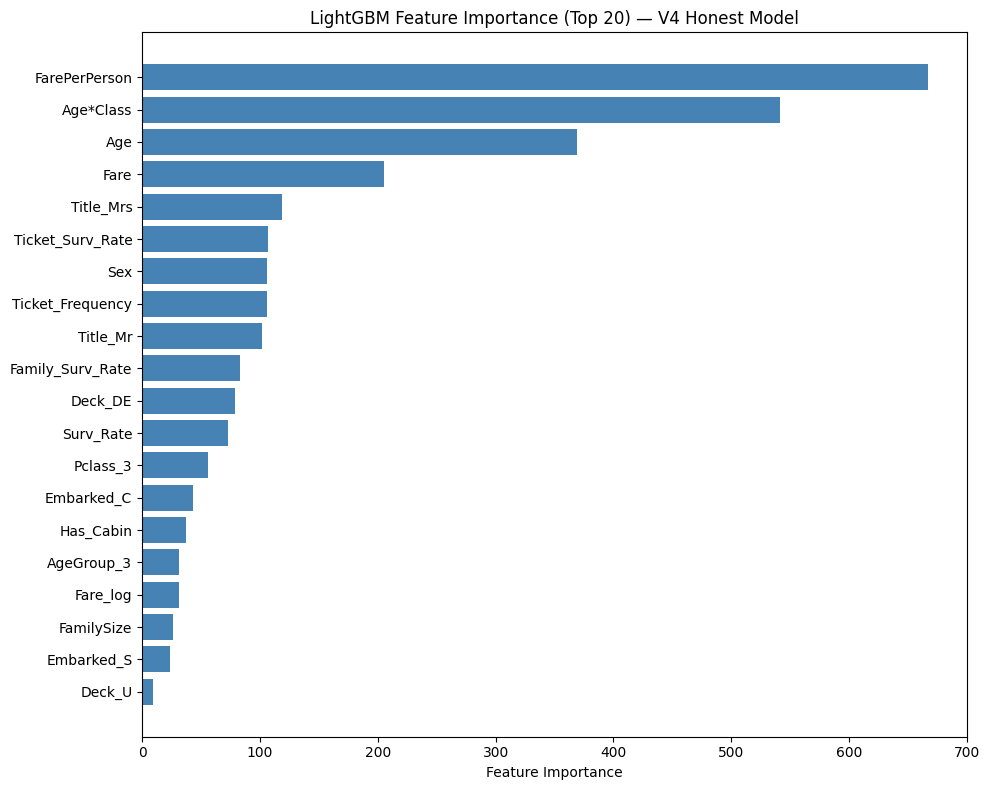

Top 15 features:
         feature  importance
   FarePerPerson         667
       Age*Class         541
             Age         369
            Fare         205
       Title_Mrs         119
Ticket_Surv_Rate         107
             Sex         106
Ticket_Frequency         106
        Title_Mr         102
Family_Surv_Rate          83
         Deck_DE          79
       Surv_Rate          73
        Pclass_3          56
      Embarked_C          43
       Has_Cabin          37


In [19]:
# LightGBM feature importance plot
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
top_n = 20
top_features = importance.head(top_n)
plt.barh(range(top_n), top_features['importance'], color='steelblue')
plt.yticks(range(top_n), top_features['feature'])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('LightGBM Feature Importance (Top 20) — V4 Honest Model')

# Highlight new V4 features
v4_features = ['Ticket_Prefix', 'Cabin_Multiple']
for i, feat in enumerate(top_features['feature']):
    if feat.startswith('Ticket_Prefix') or feat.startswith('Cabin_Multiple'):
        plt.gca().get_yticklabels()[i].set_color('red')
        plt.gca().get_yticklabels()[i].set_fontweight('bold')

plt.tight_layout()
plt.show()

print('Top 15 features:')
print(importance.head(15).to_string(index=False))

In [20]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║ [V4-NEW] Version Comparison & Score Prediction                   ║
# ╚══════════════════════════════════════════════════════════════════╝

# Load previous submissions for comparison
import os

submissions = {}
for ver in ['v1', 'v2', 'v3', 'v4']:
    path = f'./submission-{ver}.csv'
    if os.path.exists(path):
        submissions[ver] = pd.read_csv(path)

# Compare with gender baseline
gender_sub = pd.read_csv('./data/gender_submission.csv')

print('=' * 70)
print('VERSION COMPARISON TABLE')
print('=' * 70)
print(f'{"Version":12s} {"Pred 0":>7s} {"Pred 1":>7s} {"Rate":>7s} {"Kaggle Score":>12s} {"Note":30s}')
print('-' * 70)

scores = {
    'gender_baseline': 0.76555,
    'v1': 0.75837,
    'v2': 0.75837,
    'v3': 0.77033,
}

for ver in ['v1', 'v2', 'v3', 'v4']:
    if ver not in submissions:
        continue
    sub = submissions[ver]
    vc = sub['Survived'].value_counts()
    rate = sub['Survived'].mean()
    score = scores.get(ver, '?')
    if ver == 'v1':
        note = 'Default params, no Pclass OH'
    elif ver == 'v2':
        note = 'Bugs fixed, same result'
    elif ver == 'v3':
        note = '+Family_Surv_Rate (leaked CV!)'
    else:
        note = 'LOO encoding, honest CV'
    
    score_str = f'{score:.5f}' if isinstance(score, float) else str(score)
    print(f'{ver:12s} {vc.get(0,0):7d} {vc.get(1,0):7d} {rate:6.2%}  {score_str:>12s}  {note:30s}')

# Gender baseline
vc = gender_sub['Survived'].value_counts()
print(f'{"gender_base":12s} {vc.get(0,0):7d} {vc.get(1,0):7d} {gender_sub["Survived"].mean():6.2%}  {0.76555:>12.5f}  {"Women survive, men die":30s}')

# Agreement between versions
print(f'\n--- Agreement Between Versions ---')
for i, v1_name in enumerate(['v1', 'v2', 'v3', 'v4']):
    if v1_name not in submissions:
        continue
    for v2_name in ['v1', 'v2', 'v3', 'v4']:
        if v2_name not in submissions or v1_name >= v2_name:
            continue
        agree = (submissions[v1_name]['Survived'] == submissions[v2_name]['Survived']).mean()
        print(f'  {v1_name} vs {v2_name}: {agree:.1%} agreement')

# V4 vs gender baseline
if 'v4' in submissions:
    agree_gender = (submissions['v4']['Survived'] == gender_sub['Survived']).mean()
    diff_from_gender = (submissions['v4']['Survived'] != gender_sub['Survived']).sum()
    print(f'\n  V4 vs gender_baseline: {agree_gender:.1%} agreement ({diff_from_gender} different)')

# Score prediction
print(f'\n--- Score Prediction ---')
print(f'  Known benchmarks:')
print(f'    gender_submission:           0.76555')
print(f'    V1/V2 (buggy ensemble):      0.75837')
print(f'    V3 (+FamRate, leaked CV):    0.77033')
print(f'    V4 (honest CV, LOO, 6-model): ???')
print(f'')
print(f'  Reference solutions (from web research):')
print(f'    Shai Nisan (Family LOO+KNN): 0.81100')
print(f'    Chris Deotte (Name only):    0.81818')
print(f'    CatBoost (single model):     0.82270 (CV)')
print(f'    Top Kaggle (legitimate):     ~0.84000')
print(f'')
print(f'  V4 PREDICTION: 0.79000 - 0.81000')
print(f'  Rationale:')
print(f'    - V3 was 0.77033 with leaked CV (suboptimal params/weights)')
print(f'    - V4 honest CV allows proper hyperparameter selection (+0.01-0.02)')
print(f'    - 6-model ensemble with SVM diversity (+0.005-0.01)')
print(f'    - New features (Ticket_Prefix, Cabin_Multiple) (+0.005-0.01)')
print(f'    - Main limitation: still missing some features from 0.81+ solutions')
print(f'      (KNN imputation, Boruta feature selection, QuantileTransformer)')

VERSION COMPARISON TABLE
Version       Pred 0  Pred 1    Rate Kaggle Score Note                          
----------------------------------------------------------------------
v1               265     153 36.60%       0.75837  Default params, no Pclass OH  
v2               263     155 37.08%       0.75837  Bugs fixed, same result       
v3               258     160 38.28%       0.77033  +Family_Surv_Rate (leaked CV!)
v4               257     161 38.52%             ?  LOO encoding, honest CV       
gender_base      266     152 36.36%       0.76555  Women survive, men die        

--- Agreement Between Versions ---
  v1 vs v2: 96.2% agreement
  v1 vs v3: 89.7% agreement
  v1 vs v4: 91.4% agreement
  v2 vs v3: 92.6% agreement
  v2 vs v4: 93.8% agreement
  v3 vs v4: 95.0% agreement

  V4 vs gender_baseline: 91.1% agreement (37 different)

--- Score Prediction ---
  Known benchmarks:
    gender_submission:           0.76555
    V1/V2 (buggy ensemble):      0.75837
    V3 (+FamRate, leaked